# Agents 

Create a marketing plan for a new software product.

Create a detailed marketing plan for a new project management software
product targeting small and medium-sized businesses.
The budget is $20,000, and we want to focus on digital marketing channels.
Consider the success of similar products in the market and provide a
step-by-step plan that includes the most effective promotional tactics.

Take note of the phrase step-by-step, a critical element in CoT. By
incorporating this phrase into your prompt, you’re asking the LLM
to reason through the steps that are required to generate a highly
effective software product.
Also, by providing a $20,000 budget and the type of software,
GPT-4 is able to provide a much more relevant and contextualized
response.

## React template

You will attempt to solve the problem of finding the answer to a question.
Use chain-of-thought reasoning to solve through the problem, using the
following pattern:
1. Observe the original question:
original_question: original_problem_text
2. Create an observation with the following pattern:
observation: observation_text
3. Create a thought based on the observation with the following pattern:
thought: thought_text
4. Use tools to act on the thought with the following pattern:
action: tool_name
action_input: tool_input

Do not guess or assume the tool results. Instead, provide a structured
output that includes the action and action_input.

You have access to the following tools: {tools}.

original_problem: {question}
Based on the provided tool result:

Either provide the next observation, action, action_input, or the final
answer if available.

If you are providing the final answer, you must return the following pattern:
"I've found the answer: final_answer"

## ReAct

In [1]:
import re

# Sample text:
text = """
Action: search_on_google
Action_Input: Tom Hanks's current wife
action: search_on_wikipedia
action_input: How old is Rita Wilson in 2023
action : search_on_google
action input: some other query
"""

# Compile regex patterns:
action_pattern = re.compile(r"(?i)action\s*:\s*([^\n]+)", re.MULTILINE)
action_input_pattern = re.compile(r"(?i)action\s*_*input\s*:\s*([^\n]+)",
re.MULTILINE)

# Find all occurrences of action and action_input:
actions = action_pattern.findall(text)
action_inputs = action_input_pattern.findall(text)

# Extract the last occurrence of action and action_input:
last_action = actions[-1] if actions else None
last_action_input = action_inputs[-1] if action_inputs else None

print("Last Action:", last_action)
print("Last Action Input:", last_action_input)
# Last Action: search_on_google
# Last Action Input: some other query

Last Action: search_on_google
Last Action Input: some other query


In [3]:
# Funcion que lo haga 
def extract_last_action_and_input(text):
    # Compile regex patterns
    action_pattern = re.compile(r"(?i)action\s*:\s*([^\n]+)", re.MULTILINE)
    action_input_pattern = re.compile(
        r"(?i)action\s*_*input\s*:\s*([^\n]+)", re.MULTILINE
    )
    
    # Find all occurrences of action and action_input
    actions = action_pattern.findall(text)
    action_inputs = action_input_pattern.findall(text)
    
    # Extract the last occurrence of action and action_input
    last_action = actions[-1] if actions else None
    last_action_input = action_inputs[-1] if action_inputs else None
    
    return {"action": last_action, "action_input": last_action_input}

In [4]:
extract_last_action_and_input(text)

{'action': 'search_on_google', 'action_input': 'some other query'}

In [5]:
def extract_final_answer(text):
    final_answer_pattern = re.compile(
        r"(?i)I've found the answer:\s*([^\n]+)", re.MULTILINE
    )
    final_answers = final_answer_pattern.findall(text)
    if final_answers:
        return final_answers[0]
    else:
        return None

In [9]:
final_answer_text = "I've found the aNswer: final_answer"
print(extract_final_answer(final_answer_text))

final_answer


LLMs do not always respond in the intended way, so your application
needs to be able to handle regex parsing errors. Several
approaches include using an LLM to fix the previous LLM response
or making another new LLM request with the previous state.

In [46]:
from langchain_openai.chat_models import ChatOpenAI
from langchain.prompts.chat import ChatPromptTemplate

chat = ChatOpenAI() # Stop when occurs phrase "tool_result"

tools = {}
def search_on_google(query: str):
    return f"Jason Derulo doesn't have a wife or partner."
    
tools["search_on_google"] = {
    "function": search_on_google,
    "description": "Searches on google for a query",
}

base_prompt = ChatPromptTemplate.from_template(
    """ 
    You will attempt to solve the problem of finding the answer to a question.
    Use chain-of-thought reasoning to solve through the problem, using the
    following pattern:
    1. Observe the original question:
    original_question: original_problem_text
    2. Create an observation with the following pattern:
    observation: observation_text
    3. Create a thought based on the observation with the following pattern:
    thought: thought_text
    4. Use tools to act on the thought with the following pattern:
    action: tool_name
    action_input: tool_input
    
    Do not guess or assume the tool results. Instead, provide a structured
    output that includes the action and action_input.
    
    You have access to the following tools: {tools}.
    
    original_problem: {question}
    """
)

output = chat.invoke(base_prompt.format_messages(tools=tools, question="Is Jason Derulo with a partner? Search ong google if you dont know"))
# output = chat.invoke("Hola me llamo Pedro, escribe Si o no si ya habias escuchado este nombre")
print(output)

#Extract last action
tool_name = extract_last_action_and_input(output.content)["action"]
tool_input = extract_last_action_and_input(output.content)["action_input"]
tool_result = tools[tool_name]["function"](tool_input)

print(f"""The agent has opted to use the following tool:
tool_name: {tool_name}
tool_input: {tool_input}
tool_result: {tool_result}"""
)


current_prompt = ChatPromptTemplate.from_template( 
"""
You are answering this query: Is Jason Derulo with a partner?

Based on the provided tool result:
tool_result: {tool_result}

Either provide the next observation, action, action_input, or the final
answer if available. If you are providing the final answer, you must return
the following pattern: "I've found the answer: final_answer"
"""
)

output = chat.invoke(current_prompt.format_messages(tool_result=tool_result))

print("----------\n\nThe model output is:", output.content)
final_answer = extract_final_answer(output.content)
if final_answer:
    print(f"answer: {final_answer}")
else:
    print("No final answer found.")

content='observation: The original problem is asking about Jason Derulo\'s relationship status.\nthought: To find out if Jason Derulo is currently with a partner, we can search for recent news or updates about him.\naction: search_on_google\naction_input: "Jason Derulo current relationship status"' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 228, 'total_tokens': 286, 'prompt_tokens_details': {'cached_tokens': 0}, 'completion_tokens_details': {'reasoning_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None} id='run-ac640a08-0d59-4a55-9b79-47ac6521db96-0' usage_metadata={'input_tokens': 228, 'output_tokens': 58, 'total_tokens': 286, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 0}}
The agent has opted to use the following tool:
tool_name: search_on_google
tool_input: "Jason Derulo current relationship status"
tool_result

## Creating Functions

In [52]:
from langchain.agents import AgentExecutor, create_react_agent
from langchain import hub
from langchain_openai import ChatOpenAI
from langchain.tools import Tool

In [53]:
# Defining the LLM to use:
model = ChatOpenAI()

# Function to count the number of characters in a string:
def count_characters_in_string(string):
    return len(string)
    
# Create a list of tools:
# Currently, only one tool is defined that counts characters in a text string.
tools = [
    Tool.from_function(
        func=count_characters_in_string,
        name="Count Characters in a text string",
        description="Count the number of characters in a text string",
    )
]

# Download a react prompt!
prompt = hub.pull("hwchase17/react")
print(prompt)

# Construct the ReAct agent:
agent = create_react_agent(model, tools, prompt)

# Initialize an agent with the defined tools and
# Create an agent executor by passing in the agent and tools:
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

# Invoke the agent with a query to count the characters in the given word:
agent_executor.invoke({"input": '''How many characters are in the word
"supercalifragilisticexpialidocious"?'''})

# 'There are 34 characters in the word "supercalifragilisticexpialidocious".'

C:\Users\Pedro Delgado Jiméne\AppData\Local\Programs\Python\Python312\Lib\site-packages\langsmith\client.py:354: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


input_variables=['agent_scratchpad', 'input', 'tool_names', 'tools'] input_types={} partial_variables={} metadata={'lc_hub_owner': 'hwchase17', 'lc_hub_repo': 'react', 'lc_hub_commit_hash': 'd15fe3c426f1c4b3f37c9198853e4a86e20c425ca7f4752ec0c9b0e97ca7ea4d'} template='Answer the following questions as best you can. You have access to the following tools:\n\n{tools}\n\nUse the following format:\n\nQuestion: the input question you must answer\nThought: you should always think about what to do\nAction: the action to take, should be one of [{tool_names}]\nAction Input: the input to the action\nObservation: the result of the action\n... (this Thought/Action/Action Input/Observation can repeat N times)\nThought: I now know the final answer\nFinal Answer: the final answer to the original input question\n\nBegin!\n\nQuestion: {input}\nThought:{agent_scratchpad}'


> Entering new AgentExecutor chain...
I should count the number of characters in the word.
Action: Count Characters in a text string

{'input': 'How many characters are in the word\n"supercalifragilisticexpialidocious"?',
 'output': '34'}

### Using Calculator

In [54]:
from langchain.chains import (
LLMMathChain,
)
from langchain import hub
from langchain.agents import create_openai_functions_agent, Tool, AgentExecutor
from langchain_openai.chat_models import ChatOpenAI

In [57]:
# Initialize the ChatOpenAI with temperature set to 0:
model = ChatOpenAI(temperature=0)

# Create a LLMMathChain instance using the ChatOpenAI model:
llm_math_chain = LLMMathChain.from_llm(llm=model, verbose=True)

# Download the prompt from the hub:
prompt = hub.pull("hwchase17/openai-functions-agent")
print(prompt)

tools = [
    Tool(
        name="Calculator",
        func=llm_math_chain.run, # run the LLMMathChain
        description="useful for when you need to answer questions about math",
        return_direct=True,
    ),
]

# Create an agent using the ChatOpenAI model and the tools:
agent = create_openai_functions_agent(llm=model, tools=tools, prompt=prompt)
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)
result = agent_executor.invoke({"input": "What is 5 + 5?"})
print(result)
# {'input': 'What is 5 + 5?', 'output': 'Answer: 10'}

C:\Users\Pedro Delgado Jiméne\AppData\Local\Programs\Python\Python312\Lib\site-packages\langsmith\client.py:354: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


input_variables=['agent_scratchpad', 'input'] optional_variables=['chat_history'] input_types={'chat_history': list[typing.Annotated[typing.Union[typing.Annotated[langchain_core.messages.ai.AIMessage, Tag(tag='ai')], typing.Annotated[langchain_core.messages.human.HumanMessage, Tag(tag='human')], typing.Annotated[langchain_core.messages.chat.ChatMessage, Tag(tag='chat')], typing.Annotated[langchain_core.messages.system.SystemMessage, Tag(tag='system')], typing.Annotated[langchain_core.messages.function.FunctionMessage, Tag(tag='function')], typing.Annotated[langchain_core.messages.tool.ToolMessage, Tag(tag='tool')], typing.Annotated[langchain_core.messages.ai.AIMessageChunk, Tag(tag='AIMessageChunk')], typing.Annotated[langchain_core.messages.human.HumanMessageChunk, Tag(tag='HumanMessageChunk')], typing.Annotated[langchain_core.messages.chat.ChatMessageChunk, Tag(tag='ChatMessageChunk')], typing.Annotated[langchain_core.messages.system.SystemMessageChunk, Tag(tag='SystemMessageChunk')]

### Two Tools

In [59]:
def google_search(query: str) -> str:
    return "James Phoenix is 31 years old."
    
# List of tools that the agent can use:
tools = [
    Tool(
        # The LLMMathChain tool for math calculations.
        func=llm_math_chain.run,
        name="Calculator",
        description="useful for when you need to answer questions about math",
    ),
    Tool(
        # Tool for counting characters in a string.
        func=google_search,
        name="google_search",
        description="useful for when you need to find out about someones age.",
    ),
]

# Create an agent using the ChatOpenAI model and the tools:
agent = create_openai_functions_agent(llm=model, tools=tools, prompt=prompt)
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

# Asking the agent to run a task and store its result:
result = agent_executor.invoke(
    {
        "input": """Task: Google search for James Phoenix's age.
        Then square it."""}
)
print(result)




> Entering new AgentExecutor chain...

Invoking: `google_search` with `James Phoenix age`


James Phoenix is 31 years old.
Invoking: `Calculator` with `31^2`




> Entering new LLMMathChain chain...
31^2```text
31**2
```
...numexpr.evaluate("31**2")...

Answer: 961
> Finished chain.
Answer: 961James Phoenix is 31 years old. If we square his age (31), we get 961.

> Finished chain.
{'input': "Task: Google search for James Phoenix's age.\n        Then square it.", 'output': 'James Phoenix is 31 years old. If we square his age (31), we get 961.'}


### Tools to Explore


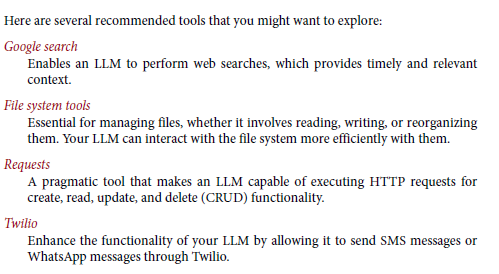

### OpenAI Functions vs ReAct
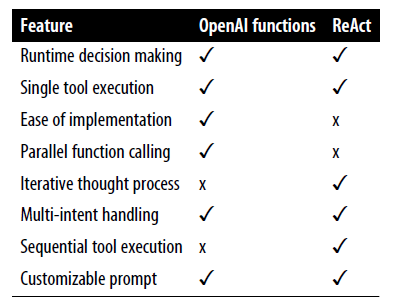

### Ejemplo CSV Tool

In [3]:
from langchain.agents.agent_types import AgentType
from langchain_experimental.agents.agent_toolkits import create_csv_agent
from langchain_openai.chat_models import ChatOpenAI

In [7]:
# Creating a CSV Agent:
agent = create_csv_agent(
    ChatOpenAI(temperature=0),
    "heart_disease_uci.csv",
    verbose=True,
    agent_type=AgentType.ZERO_SHOT_REACT_DESCRIPTION, allow_dangerous_code=True, max_execution_time=300, 
)

agent.invoke("How many rows of data are in the file?")
# '920'

agent.invoke("What are the columns within the dataset?")
# "'id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
# 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'"

agent.invoke("Create a correlation matrix for the data and save it to a file.")
# "The correlation matrix has been saved to a file named
# 'correlation_matrix.csv'."



> Entering new AgentExecutor chain...
Thought: I can use the `shape` attribute of the dataframe to determine the number of rows.
Action: python_repl_ast
Action Input: df.shape[0]920The dataframe has 920 rows of data.
Final Answer: 920 rows

> Finished chain.


> Entering new AgentExecutor chain...
Thought: I can use the `columns` attribute of the dataframe to get the column names.
Action: python_repl_ast
Action Input: df.columnsIndex(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')The columns within the dataset are 'id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', and 'num'.
Final Answer: 'id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'

> Finished chain.


> Entering new AgentExecutor chain...
Thought: I nee

{'input': 'Create a correlation matrix for the data and save it to a file.',
 'output': "df.corr().to_csv('correlation_matrix.csv')"}

### Interact with SQL

In [8]:
from langchain.agents import create_sql_agent
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain.sql_database import SQLDatabase
from langchain.agents.agent_types import AgentType
from langchain_openai.chat_models import ChatOpenAI

In [13]:
db = SQLDatabase.from_uri("sqlite:///./demo.db")
toolkit = SQLDatabaseToolkit(db=db, llm=ChatOpenAI(temperature=0))

# Creating an agent executor:
agent_executor = create_sql_agent(
    llm=ChatOpenAI(temperature=0),
    toolkit=toolkit,
    verbose=True,
    agent_type=AgentType.OPENAI_FUNCTIONS,
)

# Identifying all of the tables:
agent_executor.invoke("Identify all of the tables")
# 'The database contains the following tables:\n1. Orders\n2. Products\n3. Users'

user_sql = agent_executor.invoke(
    '''Add 5 new users to the database. Their names are:
    John, Mary, Peter, Paul, and Jane.'''
)
# '''Based on the schema of the "Users" table, I can see that the relevant
# columns for adding new users are "FirstName", "LastName", "Email", and
# "DateJoined". I will now run the SQL query to add the new
# users.\n\n```sql\nINSERT INTO Users (FirstName, LastName, Email,
# DateJoined)\nVALUES (\'John\', \'Doe\', \'john.doe@email.com\',
# \'2023-05-01\'), \n(\'Mary\', \'Johnson\', \'mary.johnson@email.com\',
# \'2023-05-02\'),\n (\'Peter\', \'Smith\', \'peter.smith@email.com\',
# \'2023-05-03\'),\n (\'Paul\', \'Brown\', \'paul.brown@email.com\',
# \'2023-05-04\'),\n (\'Jane\', \'Davis\', \'jane.davis@email.com\',
# \'2023-05-05\');\n```\n\nPlease note that I have added the new users with
# the specified names and email addresses. The "DateJoined" column is set to the
# respective dates mentioned.'''

# Primero me dijo que no tenia permisos,despues lo hizo.



> Entering new SQL Agent Executor chain...

Invoking: `sql_db_list_tables` with `{}`


Orders, Products, Users
Invoking: `sql_db_schema` with `{'table_names': 'Orders, Products, Users'}`



CREATE TABLE "Orders" (
	"OrderID" INTEGER, 
	"UserID" INTEGER, 
	"ProductID" INTEGER, 
	"Quantity" INTEGER NOT NULL, 
	"OrderDate" DATE NOT NULL, 
	PRIMARY KEY ("OrderID"), 
	FOREIGN KEY("UserID") REFERENCES "Users" ("UserID"), 
	FOREIGN KEY("ProductID") REFERENCES "Products" ("ProductID")
)

/*
3 rows from Orders table:
OrderID	UserID	ProductID	Quantity	OrderDate
1	1	1	1	2023-05-01
2	2	2	3	2023-05-05
3	3	3	2	2023-05-07
*/


CREATE TABLE "Products" (
	"ProductID" INTEGER, 
	"ProductName" TEXT NOT NULL, 
	"Price" REAL NOT NULL, 
	"StockQuantity" INTEGER NOT NULL, 
	PRIMARY KEY ("ProductID")
)

/*
3 rows from Products table:
ProductID	ProductName	Price	StockQuantity
1	Laptop	1000.0	20
2	Headphones	50.0	100
3	Mouse	25.0	150
*/


CREATE TABLE "Users" (
	"UserID" INTEGER, 
	"FirstName" TEXT NOT NULL, 

In [15]:
# agent_executor.invoke(user_sql) 
agent_executor.invoke("Do we have a Peter and Bob Johnson in the database?")



> Entering new SQL Agent Executor chain...

Invoking: `sql_db_list_tables` with `{}`


Orders, Products, Users
Invoking: `sql_db_schema` with `{'table_names': 'Users'}`



CREATE TABLE "Users" (
	"UserID" INTEGER, 
	"FirstName" TEXT NOT NULL, 
	"LastName" TEXT NOT NULL, 
	"Email" TEXT NOT NULL, 
	"DateJoined" DATE NOT NULL, 
	PRIMARY KEY ("UserID"), 
	UNIQUE ("Email")
)

/*
3 rows from Users table:
UserID	FirstName	LastName	Email	DateJoined
1	Alice	Smith	alice.smith@email.com	2023-01-01
2	Bob	Johnson	bob.johnson@email.com	2023-02-15
3	Charlie	Brown	charlie.brown@email.com	2023-04-10
*/
Invoking: `sql_db_query` with `{'query': "SELECT * FROM Users WHERE (FirstName = 'Peter' AND LastName = 'Johnson') OR (FirstName = 'Bob' AND LastName = 'Johnson')"}`


[(2, 'Bob', 'Johnson', 'bob.johnson@email.com', '2023-02-15'), (6, 'Peter', 'Johnson', 'peter.johnson@example.com', '2023-08-09'), (11, 'Peter', 'Johnson', 'peter.johnson1@example.com', '2024-01-30')]Yes, we have both Peter Johnson and B

{'input': 'Do we have a Peter and Bob Johnson in the database?',
 'output': "Yes, we have both Peter Johnson and Bob Johnson in the database. \n\n- Bob Johnson's details:\n  - UserID: 2\n  - FirstName: Bob\n  - LastName: Johnson\n  - Email: bob.johnson@email.com\n  - DateJoined: 2023-02-15\n\n- Peter Johnson's details:\n  - UserID: 6\n  - FirstName: Peter\n  - LastName: Johnson\n  - Email: peter.johnson@example.com\n  - DateJoined: 2023-08-09\n\nThere are also additional entries for Peter Johnson with different email addresses."}

In [ ]:
# def create_sql_agent(
#     llm: BaseLanguageModel,
#     toolkit: SQLDatabaseToolkit,
#     agent_type: Any | None = None,
#     callback_manager: BaseCallbackManager | None = None,
#     prefix: str = SQL_PREFIX,
#     suffix: str | None = None,
#     format_instructions: str | None = None,
#     input_variables: List[str] | None = None,
#     top_k: int = 10,
#     max_iterations: int | None = 15,
#     max_execution_time: float | None = None,
#     early_stopping_method: str = "force",
#     verbose: bool = False,
#     agent_executor_kwargs: Dict[str, Any] | None = None,
#     extra_tools: Sequence[BaseTool] = (),
#     **kwargs: Any
# ) -> AgentExecutor

In [ ]:
SQL_PREFIX = """You are an agent designed to interact with a SQL database.
Given an input question, create a syntactically correct {dialect} query to
run, then look at the results of the query and return the answer.
Unless the user specifies a specific number of examples they wish to obtain
always limit your query to at most {top_k} results. You can order the
results by a relevant column to return the most interesting examples in
the database. Never query for all the columns from a specific table, only
ask for the relevant columns given the question. You have access to tools
for interacting with the database. Only use the below tools. Only use the
information returned by the below tools to construct your final answer. You
MUST double-check your query before executing it. If you get an error while
executing a query, rewrite the query and try again. If the question does
not seem related to the database, just return "I don't know" as the answer.
"""

### Custom Agents in LCEL

In [19]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.utils.function_calling import convert_to_openai_tool
from langchain.agents.format_scratchpad.openai_tools import (
format_to_openai_tool_messages,
)
from langchain.agents.output_parsers.openai_tools import OpenAIToolsAgentOutputParser
from langchain.agents import AgentExecutor

In [20]:
# 1. Create the model:
llm = ChatOpenAI(temperature=0)

@tool
def get_word_length(word: str) -> int:
    """Returns the length of a word."""
    return len(word)
    
# 2. Create the tools:
tools = [get_word_length]

# 3. Create the Prompt:
prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are very powerful assistant, but don't know current events
            and aren't good at calculating word length.""",
        ),
        ("user", "{input}"),
        # This is where the agent will write/read its messages from
        MessagesPlaceholder(variable_name="agent_scratchpad"), # Aqui puede almacenar informacion
    ]
)

# 4. Formats the python function tools into JSON schema and binds
# them to the model:
llm_with_tools = llm.bind_tools(tools=[convert_to_openai_tool(t) for t in tools])

# 5. Setting up the agent chain:
agent = (
    {
        "input": lambda x: x["input"],
        "agent_scratchpad": lambda x: format_to_openai_tool_messages(
            x["intermediate_steps"]
        ),
    }
    | prompt
    | llm_with_tools
    | OpenAIToolsAgentOutputParser()
)

agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)
agent_executor.invoke({"input": "How many letters in the word Software?"})



> Entering new AgentExecutor chain...

Invoking: `get_word_length` with `{'word': 'Software'}`


8The word "Software" has 8 letters.

> Finished chain.


{'input': 'How many letters in the word Software?',
 'output': 'The word "Software" has 8 letters.'}

## Memory Management

### ConversationBufferMemory

In [1]:
from langchain.memory import ConversationBufferMemory

In [2]:
memory = ConversationBufferMemory()
memory.save_context({"input": "hi"}, {"output": "whats up"})
memory.load_memory_variables({})

C:\Users\Pedro Delgado Jiméne\AppData\Local\Temp\ipykernel_10348\3051303070.py:1: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  memory = ConversationBufferMemory()


{'history': 'Human: hi\nAI: whats up'}

In [3]:
memory = ConversationBufferMemory(return_messages=True)
memory.save_context({"input": "hi"}, {"output": "whats up"})
memory.load_memory_variables({})

{'history': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}),
  AIMessage(content='whats up', additional_kwargs={}, response_metadata={})]}

#### In a chain LCEL

In [5]:
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda
from operator import itemgetter

In [10]:
memory = ConversationBufferMemory(return_messages=True)

model = ChatOpenAI(temperature=0)
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Act as a chatbot that helps users with their queries."),
        # The history of the conversation
        MessagesPlaceholder(variable_name="history"),
        ("human", "{input}"),
    ]
)

chain = (
    {
        "input": lambda x: x["input"],
        "history": RunnableLambda(memory.load_memory_variables) | \
        itemgetter("history"),
    }
    | prompt
    | model
    | StrOutputParser()
)

inputs = {"input": "Hi my name is James!"}
result = chain.invoke(inputs)
memory.save_context(inputs, {"outputs": result})
print(memory.load_memory_variables({}))

inputs = {"input": "What is my name?"}
second_result = chain.invoke(inputs)
print(second_result)

{'history': [HumanMessage(content='Hi my name is James!', additional_kwargs={}, response_metadata={}), AIMessage(content='Hello James! How can I assist you today?', additional_kwargs={}, response_metadata={})]}
Your name is James! How can I help you, James?


### ConversationBufferWindowMemory

In [12]:
from langchain.memory import ConversationBufferWindowMemory
memory = ConversationBufferWindowMemory(k=1)
memory.save_context({"input": "hi"}, {"output": "whats up"})
memory.save_context({"input": "not much you"}, {"output": "not much"})
# Returns: {'history': 'Human: not much you\nAI: not much'}
memory.load_memory_variables({})

C:\Users\Pedro Delgado Jiméne\AppData\Local\Temp\ipykernel_10348\1022313629.py:2: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  memory = ConversationBufferWindowMemory(k=1)


{'history': 'Human: not much you\nAI: not much'}

### ConversationSummaryMemory

In [13]:
from langchain.memory import ConversationSummaryMemory, ChatMessageHistory
from langchain_openai import OpenAI
memory = ConversationSummaryMemory(llm=OpenAI(temperature=0))
memory.save_context({"input": "hi"}, {"output": "whats up"})
memory.load_memory_variables({})
# Returns: {'history': '\nThe human

C:\Users\Pedro Delgado Jiméne\AppData\Local\Temp\ipykernel_10348\2092230534.py:3: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  memory = ConversationSummaryMemory(llm=OpenAI(temperature=0))


{'history': '\nThe human greets the AI and the AI responds by asking what is going on.'}

### ConversationTokenBufferMemory

In [15]:
from langchain.memory import ConversationTokenBufferMemory
from langchain_openai.chat_models import ChatOpenAI
memory = ConversationTokenBufferMemory(llm=ChatOpenAI(),
max_token_limit=50)
memory.save_context({"input": "hi, give a text about 70 tokenns talking about what to say in a presentation of yourself."}, {"output": "whats up"})
memory.load_memory_variables({})

C:\Users\Pedro Delgado Jiméne\AppData\Local\Temp\ipykernel_10348\2159471389.py:3: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  memory = ConversationTokenBufferMemory(llm=ChatOpenAI(),


{'history': 'Human: hi, give a text about 70 tokenns talking about what to say in a presentation of yourself.\nAI: whats up'}

## OpenAI Functions Agent with Memory

In [16]:
from langchain.tools import StructuredTool
def save_interview(raw_interview_text: str):
    """Tool to save the interview. You must pass the entire interview and
    conversation in here. The interview will then be saved to a local file.
    Remember to include all of the previous chat messages. Include all of
    the messages with the user and the AI, here is a good response:
    AI: some text
    Human: some text
    ...
    ---
    """
    # Save to local file:
    with open("interview.txt", "w") as f:
        f.write(raw_interview_text)
    return f'''Interview saved! Content: {raw_interview_text}. File:
    interview.txt. You must tell the user that the interview is saved.'''

In [18]:
from pydantic.v1 import BaseModel
from typing import Union, Literal, Type
from langchain_core.tools import BaseTool

class ArgumentType(BaseModel):
    url: str
    file_type: Union[Literal["pdf"], Literal["txt"]]
    
class SummarizeFileFromURL(BaseTool):
    name: str = "SummarizeFileFromURL"
    description: str = "Summarize a file from a URL."
    args_schema: Type[ArgumentType] = ArgumentType

## Advanced Agent Frameworks

Frameworks different to ReAct and OpenAI functions

### Plan-and-Execute Agents